# Data Preparation (filtered)



In [ ]:
!pip install pydicom
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from google.colab import auth
from google.cloud import bigquery, storage

# Authenticate and set up environment
auth.authenticate_user()
project_id = 'mcxrp-429811'
os.environ["GOOGLE_CLOUD_PROJECT"] = project_id
!gcloud config set project {project_id}

# Initialize BigQuery client
client = bigquery.Client(project=project_id)

# Initialize GCP Storage client with user_project parameter
storage_client = storage.Client(project=project_id)
bucket_name = 'cxr_embedding'
bucket = storage_client.bucket(bucket_name, user_project=project_id)

# Path to the filtered combined data CSV in your GCP bucket
filtered_data_path = 'filtered_data1.csv'
filtered_blob = bucket.blob(filtered_data_path)

# Download the filtered combined data CSV to a local temporary file
local_filtered_data_path = '/tmp/filtered_combined_data.csv'
filtered_blob.download_to_filename(local_filtered_data_path)

# Load the filtered combined data CSV into a DataFrame
df = pd.read_csv(local_filtered_data_path)


# Extract embedding vectors
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]
print (embeddings)

Updated property [core/project].
     embedding_0  embedding_1  embedding_2  embedding_3  embedding_4  \
0       0.321410    -1.704959    -0.065366    -3.842020    -0.509893   
1      -0.876179    -1.171630     0.790065    -2.370913     0.001147   
2      -1.135697    -1.171057     0.667447    -1.922262    -0.545596   
3      -0.987584    -1.257971     1.228785    -2.585444    -0.055288   
4      -0.747503    -0.958317     1.026260    -1.702445    -0.158091   
..           ...          ...          ...          ...          ...   
347    -1.363794    -1.546389     0.327172    -2.818618     0.195265   
348    -0.863999    -0.473056     0.314768    -1.994758     0.620791   
349    -0.966310     0.006182     0.836140    -2.643983     0.148093   
350    -0.811750    -0.847627     0.069263    -2.080205    -0.475653   
351    -0.440193    -1.591327     1.234919    -1.755633    -0.310573   

     embedding_5  embedding_6  embedding_7  embedding_8  embedding_9  ...  \
0       0.997059     0.18

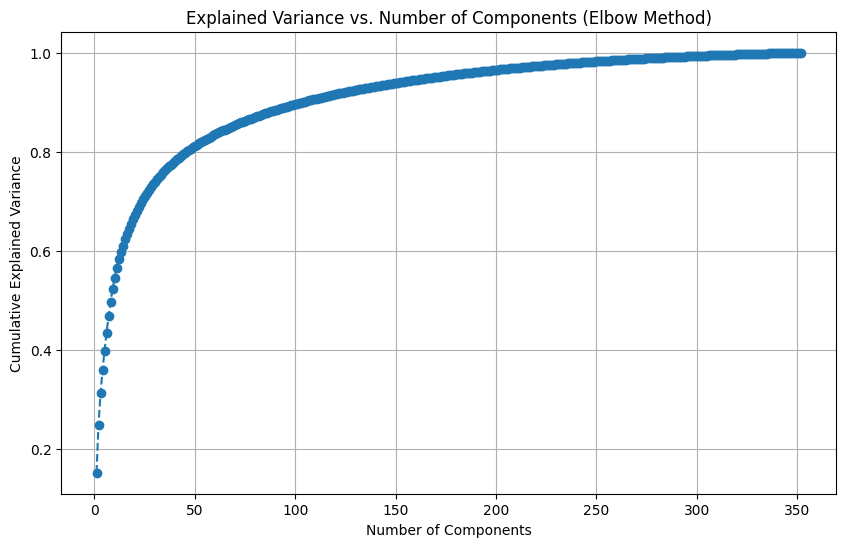

The optimal number of components based on silhouette score is: 50
[[ 2.25096060e+01 -4.06766513e+00  1.13142570e+01 ...  7.13755507e-03
  -2.44219840e-01  1.35465464e+00]
 [-1.35364197e+00  1.65389313e+00 -3.19906812e+00 ... -8.97527311e-01
  -1.17076556e+00  3.63484920e-01]
 [-7.91695956e+00 -4.61597764e+00 -4.96759944e+00 ...  7.67856087e-01
   1.39700189e-01  1.17102325e+00]
 ...
 [ 2.73964751e+00  2.49335282e+00 -2.40369801e+00 ...  1.31762896e+00
   7.97188301e-01 -4.52247872e-01]
 [-2.51021610e+00 -4.82128888e+00  3.10249051e+00 ...  6.41342724e-01
  -5.93245249e-01 -1.14179924e+00]
 [-7.00576192e-01  6.56668994e+00 -1.87019975e+00 ...  8.68237228e-01
  -2.77851006e-01 -4.48727939e-02]]
50
352


In [ ]:
# Determine the optimal number of PCA components using the elbow method
pca = PCA()
embeddings_pca = pca.fit_transform(embeddings)
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot the explained variance to use the elbow method
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components (Elbow Method)')
plt.grid()
plt.show()

# Using the Silhouette method to determine the optimal number of components
def optimal_number_of_components(data, max_components=10):
    silhouette_scores = []
    for n_components in range(2, max_components + 1):
        pca = PCA(n_components=n_components)
        transformed_data = pca.fit_transform(data)
        kmeans = KMeans(n_clusters=n_components, n_init=10)  # Explicitly set n_init
        kmeans.fit(transformed_data)
        score = silhouette_score(transformed_data, kmeans.labels_)
        silhouette_scores.append(score)

    plt.figure(figsize=(10, 6))
    plt.plot(range(2, max_components + 1), silhouette_scores, marker='o', linestyle='--')
    plt.xlabel('Number of Components')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Score vs. Number of Components')
    plt.grid()
    plt.show()

    optimal_components = np.argmax(silhouette_scores) + 2  # +2 because range starts at 2
    return optimal_components

# Display optimal number of features using silhouette score
optimal_components = 50
print(f'The optimal number of components based on silhouette score is: {optimal_components}')

# Apply PCA with optimal number of components
pca = PCA(n_components=optimal_components)
embeddings_pca = pca.fit_transform(embeddings)

# Add PCA components to the dataframe
for i in range(embeddings_pca.shape[1]):
    df[f'pca_{i+1}'] = embeddings_pca[:, i]

print (embeddings_pca)
print (len(embeddings_pca[0]))
print (len(embeddings_pca))

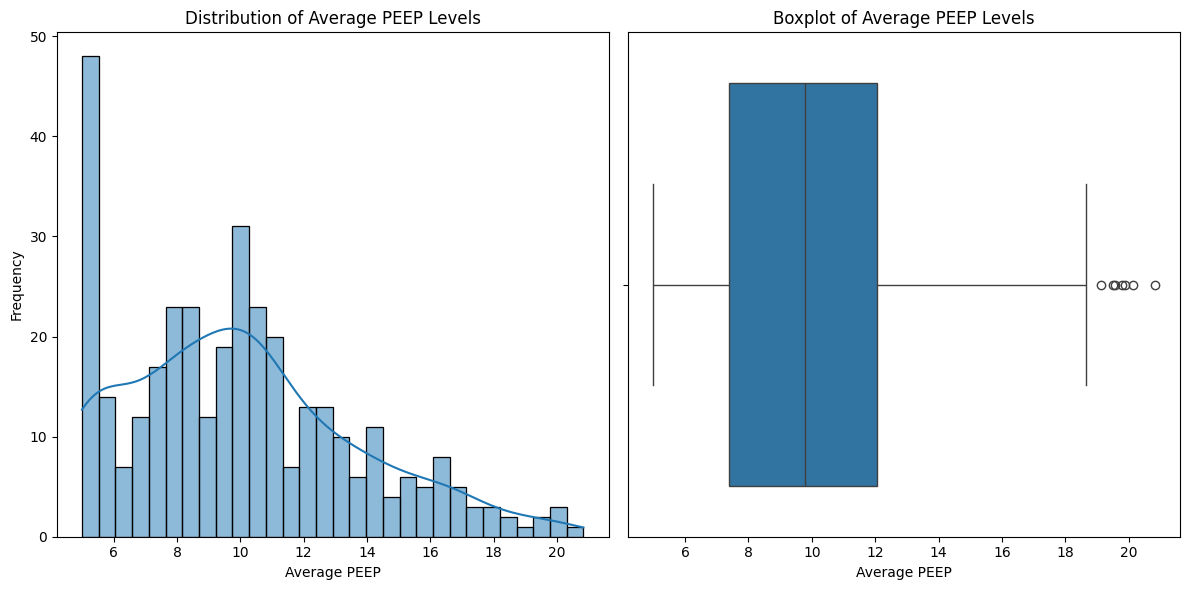

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming embeddings and avg_peep are loaded into df
# Load your dataset into a pandas DataFrame
# df = pd.read_csv('your_dataset.csv')

# Extract the avg_peep column
avg_peep = df['avg_peep']

# Plot the distribution of avg_peep levels
plt.figure(figsize=(12, 6))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(avg_peep, bins=30, kde=True)
plt.xlabel('Average PEEP')
plt.ylabel('Frequency')
plt.title('Distribution of Average PEEP Levels')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=avg_peep)
plt.xlabel('Average PEEP')
plt.title('Boxplot of Average PEEP Levels')

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd

# Assuming df is your DataFrame and avg_peep is the column of interest
# Load your dataset into a pandas DataFrame
# df = pd.read_csv('your_dataset.csv')

# Extract the avg_peep column
avg_peep = df['avg_peep']

# Count the number of data points in each range
less_than_10 = (avg_peep < 10).sum()
#between_8_and_11 = ((avg_peep >= 8) & (avg_peep <= 11)).sum()
#greater_than_11 = (avg_peep > 11).sum()

# Print the counts
print(f'Number of avg_peep data points less than 8: {less_than_10}')
#print(f'Number of avg_peep data points between 8 and 12: {between_8_and_11}')
#print(f'Number of avg_peep data points greater than or equal to 10: {greater_than_11}')


Number of avg_peep data points less than 8: 182


In [ ]:
# Choose the number of components based on the elbow method graph
chosen_components = 50

# Apply PCA with chosen number of components
pca = PCA(n_components=chosen_components)
embeddings_pca = pca.fit_transform(embeddings)

# Add PCA components to the dataframe
for i in range(embeddings_pca.shape[1]):
    df[f'pca_{i+1}'] = embeddings_pca[:, i]
    print(df[f'pca_{i+1}'])

# Prepare the data for regression analysis
X = df[[f'pca_{i+1}' for i in range(chosen_components)]]
y = df['avg_peep']

# Univariate PCA logistic regression (changing from multivariate to univariate)
# Here we use each PCA component individually to fit the regression model
significant_components = []
for i in range(chosen_components):
    Xi = sm.add_constant(X[[f'pca_{i+1}']])
    model = sm.OLS(y, Xi)
    result = model.fit()
    p_value = result.pvalues[f'pca_{i+1}']
    if p_value < 0.2:
        significant_components.append(i+1)
        #print(f'Regression summary for PCA component {i+1}')
        #print(result.summary())
print (significant_components)

0      22.509606
1      -1.353642
2      -7.916960
3       0.713120
4      -5.420800
         ...    
347    -3.147091
348     1.543191
349     2.739648
350    -2.510216
351    -0.700576
Name: pca_1, Length: 352, dtype: float64
0     -4.067665
1      1.653893
2     -4.615978
3      3.998881
4     -1.109710
         ...   
347    3.881202
348    2.253203
349    2.493353
350   -4.821289
351    6.566690
Name: pca_2, Length: 352, dtype: float64
0      11.314257
1      -3.199068
2      -4.967599
3      -2.656224
4      -1.019821
         ...    
347     2.366236
348    -1.879204
349    -2.403698
350     3.102490
351    -1.870199
Name: pca_3, Length: 352, dtype: float64
0      5.639073
1     -7.370498
2     -2.186369
3      0.199891
4     -5.422444
         ...   
347    0.839456
348   -3.856148
349   -3.499026
350    5.051911
351    4.130037
Name: pca_4, Length: 352, dtype: float64
0     -4.061323
1      0.697035
2     -4.285170
3      7.859409
4      1.727896
         ...   
347    3.04955

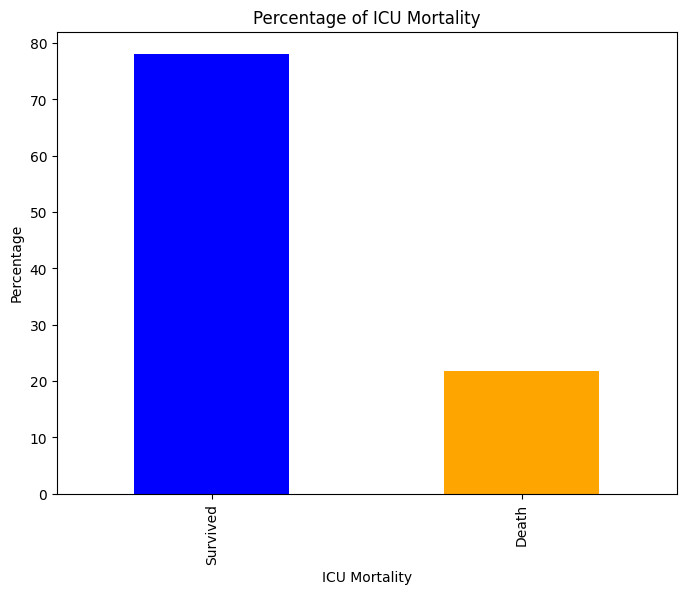

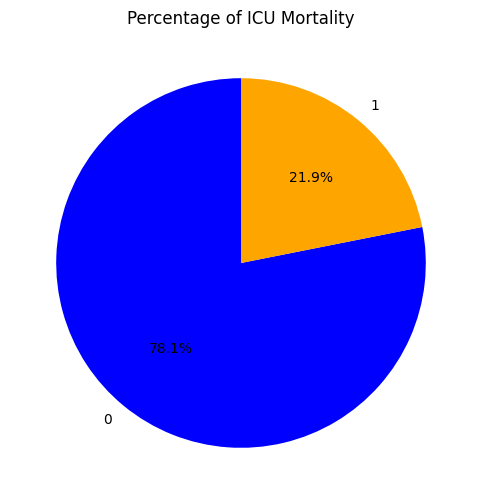

In [ ]:
import matplotlib.pyplot as plt

# Calculate the percentage of icu_mort = 1 and 0
mortality_counts = df['icu_mort'].value_counts(normalize=True) * 100

# Bar Plot
plt.figure(figsize=(8, 6))
mortality_counts.plot(kind='bar', color=['blue', 'orange'])
plt.xlabel('ICU Mortality')
plt.ylabel('Percentage')
plt.title('Percentage of ICU Mortality')
plt.xticks(ticks=[0, 1], labels=['Survived', 'Death'])
plt.show()

# Pie Chart
plt.figure(figsize=(8, 6))
mortality_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['blue', 'orange'])
plt.title('Percentage of ICU Mortality')
plt.ylabel('')  # Hide the y-label
plt.show()


# Logistic regression (filtered)

Best parameters: {'C': 0.01}
Cross-Validation Accuracy scores: [0.5483871  0.58064516 0.5483871  0.70967742 0.5       ]
Mean CV Accuracy: 0.5774193548387097


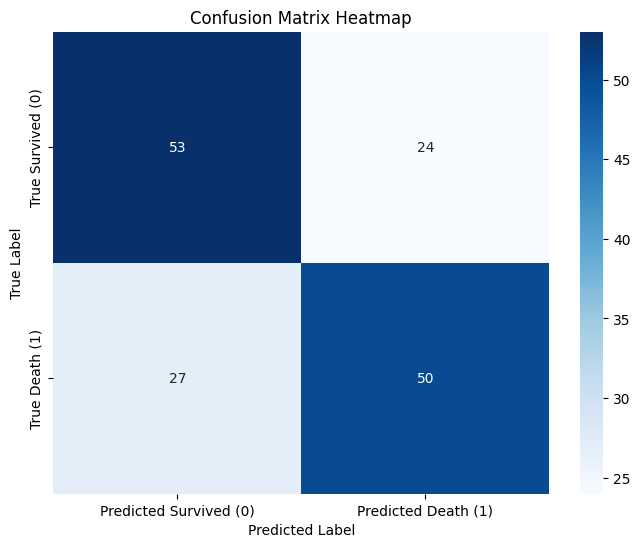

              precision    recall  f1-score   support

Survived (0)       0.66      0.69      0.68        77
   Death (1)       0.68      0.65      0.66        77

    accuracy                           0.67       154
   macro avg       0.67      0.67      0.67       154
weighted avg       0.67      0.67      0.67       154

Overall Accuracy: 0.6688311688311688
AUROC: 0.6911789509192107


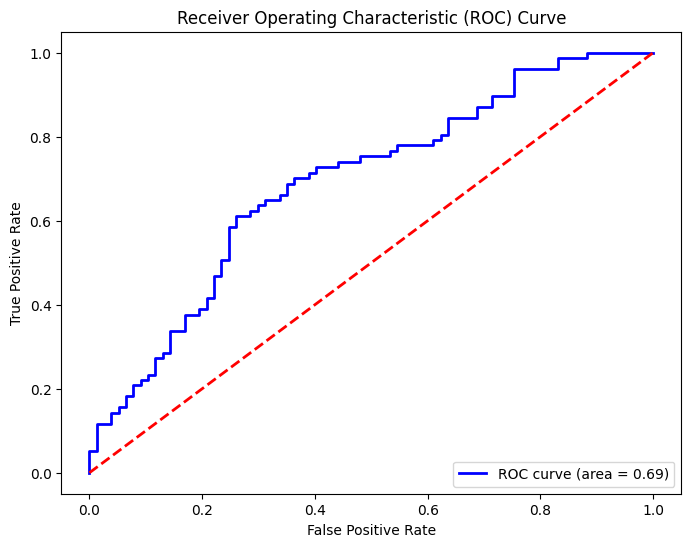


Correct Predictions:
     study_id  subject_id           study_datetime  \
41   53391370    10992814  2114-06-11 17:10:56.039   
181  52742005    14720260  2171-03-21 00:24:47.234   
167  59226066    14280192  2163-10-13 21:36:11.953   
279  52077215    17539265  2182-06-10 07:26:03.625   
263  55874195    17125981  2152-12-21 08:55:46.039   

                                  path  \
41   files/p10/p10992814/s53391370.txt   
181  files/p14/p14720260/s52742005.txt   
167  files/p14/p14280192/s59226066.txt   
279  files/p17/p17539265/s52077215.txt   
263  files/p17/p17125981/s55874195.txt   

                                         dicom_id             timezero  \
41   7f938ee9-d7e12901-72879fdc-4082cff0-58f78efd  2114-06-11 16:55:00   
181  a91a3b41-b6c38e76-1e817607-cbec0b83-675ecc19  2171-03-21 01:21:00   
167  fa8f9f79-185d07f3-966a9645-9355949a-2d930ac5  2163-10-13 20:35:00   
279  13da6fcb-9fc76e84-7f346cfc-ab74e5e2-a0656fad  2182-06-10 12:13:00   
263  ba008f0c-704cad70-2c304e8

In [ ]:
#Only using Significant PCA featuers for linear regression + Without cross validation

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming embeddings and icu_mortality are loaded into df
# Load your dataset into a pandas DataFrame
# df = pd.read_csv('your_dataset.csv')

# Extract embedding vectors and icu_mortality
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]
mortality = df['icu_mort']

# Balance the classes
df_0 = df[df['icu_mort'] == 0]
df_1 = df[df['icu_mort'] == 1]

# Undersample the majority class (icu_mort = 0) to match the minority class (icu_mort = 1)
if len(df_0) > len(df_1):
    df_0 = df_0.sample(len(df_1), random_state=42)
else:
    df_1 = df_1.sample(len(df_0), random_state=42)

# Combine the balanced data
df_balanced = pd.concat([df_0, df_1])

# Extract the balanced embeddings and mortality
embeddings_balanced = df_balanced[embedding_columns]
mortality_balanced = df_balanced['icu_mort']

# Apply PCA
pca = PCA(n_components=50)
embeddings_pca = pca.fit_transform(embeddings_balanced)

# Add PCA components to the DataFrame
for i in range(embeddings_pca.shape[1]):
    df_balanced[f'pca_{i+1}'] = embeddings_pca[:, i]

# Prepare the data for classification analysis
#X = df_balanced[[f'pca_{i+1}' for i in range(50)]]
significant_component_columns = [f'pca_{i}' for i in significant_components]
X = df_balanced[significant_component_columns]
y = mortality_balanced

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define the classification model
model = LogisticRegression(max_iter=500, penalty='l2', solver='lbfgs')  # Increase max_iter for convergence

# Perform cross-validation and hyperparameter tuning
param_grid = {'C': [0.01, 0.1, 1.0, 10.0, 100.0]}  # Adding more values for C to explore regularization effect
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_scaled, y)

# Best model from grid search
best_model = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)

# Train the best model on the full dataset
best_model.fit(X_scaled, y)

# Cross-validation scores
cv_scores = cross_val_score(best_model, X_scaled, y, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

# Predict on the entire dataset
y_pred = best_model.predict(X_scaled)
y_pred_prob = best_model.predict_proba(X_scaled)[:, 1]

# Add predictions to the DataFrame
df_balanced['predicted_icu_mortality'] = y_pred

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Survived (0)', 'Predicted Death (1)'], yticklabels=['True Survived (0)', 'True Death (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

# Print the classification report
print(classification_report(y, y_pred, target_names=['Survived (0)', 'Death (1)']))

# Calculate and print the accuracy score
accuracy = accuracy_score(y, y_pred)
print("Overall Accuracy:", accuracy)

# Calculate and print the AUROC score
roc_auc = roc_auc_score(y, y_pred_prob)
print("AUROC:", roc_auc)

# Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Identify correct and incorrect predictions
correct_predictions = df_balanced.index[y == y_pred]
incorrect_predictions = df_balanced.index[y != y_pred]

# Display some rows from the raw dataset where predictions were correct
print("\nCorrect Predictions:")
print(df_balanced.loc[correct_predictions].head())

# Display some rows from the raw dataset where predictions were incorrect
print("\nIncorrect Predictions:")
print(df_balanced.loc[incorrect_predictions].head())


Best parameters: {'C': 0.01}
Cross-Validation Accuracy scores: [0.61290323 0.5483871  0.61290323 0.4516129  0.7       ]
Mean CV Accuracy: 0.5851612903225807


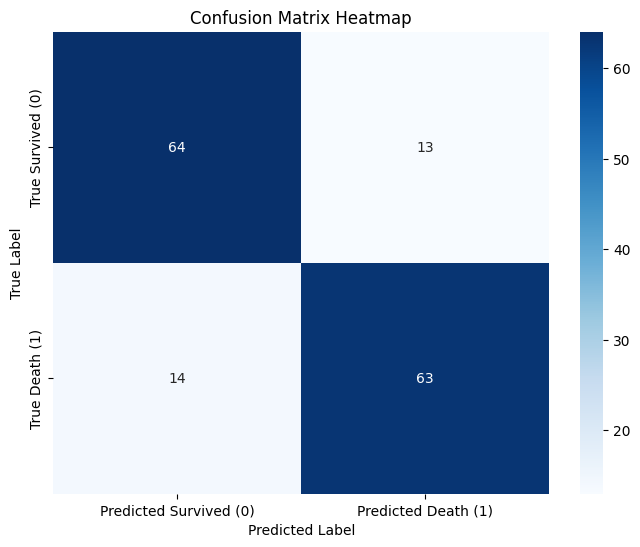

              precision    recall  f1-score   support

Survived (0)       0.82      0.83      0.83        77
   Death (1)       0.83      0.82      0.82        77

    accuracy                           0.82       154
   macro avg       0.82      0.82      0.82       154
weighted avg       0.82      0.82      0.82       154

Overall Accuracy: 0.8246753246753247
AUROC: 0.9099342216225333


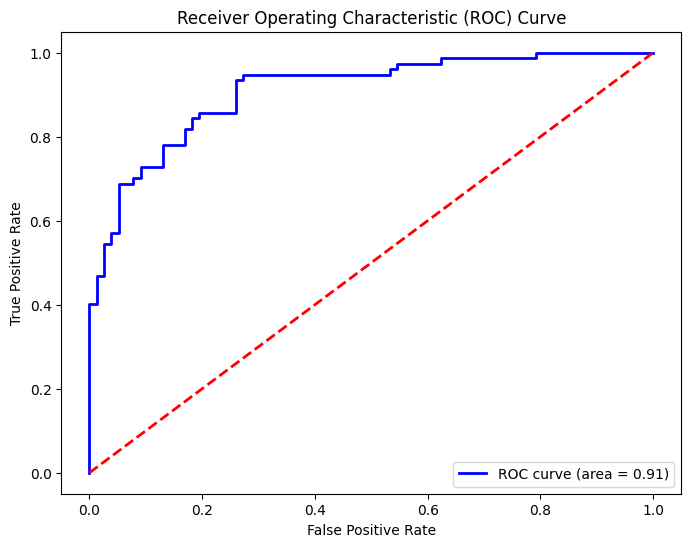


Correct Predictions:
     study_id  subject_id           study_datetime  \
41   53391370    10992814  2114-06-11 17:10:56.039   
181  52742005    14720260  2171-03-21 00:24:47.234   
254  54895239    16892349  2147-09-23 11:03:49.811   
167  59226066    14280192  2163-10-13 21:36:11.953   
279  52077215    17539265  2182-06-10 07:26:03.625   

                                  path  \
41   files/p10/p10992814/s53391370.txt   
181  files/p14/p14720260/s52742005.txt   
254  files/p16/p16892349/s54895239.txt   
167  files/p14/p14280192/s59226066.txt   
279  files/p17/p17539265/s52077215.txt   

                                         dicom_id             timezero  \
41   7f938ee9-d7e12901-72879fdc-4082cff0-58f78efd  2114-06-11 16:55:00   
181  a91a3b41-b6c38e76-1e817607-cbec0b83-675ecc19  2171-03-21 01:21:00   
254  f52a9875-e0e6eb2f-4e7bb7f0-d7bae991-71c55d9f  2147-09-23 17:06:00   
167  fa8f9f79-185d07f3-966a9645-9355949a-2d930ac5  2163-10-13 20:35:00   
279  13da6fcb-9fc76e84-7f346cf

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming embeddings and icu_mortality are loaded into df
# Load your dataset into a pandas DataFrame
# df = pd.read_csv('your_dataset.csv')

# Extract embedding vectors and icu_mortality
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]
mortality = df['icu_mort']

# Balance the classes
df_0 = df[df['icu_mort'] == 0]
df_1 = df[df['icu_mort'] == 1]

# Undersample the majority class (icu_mort = 0) to match the minority class (icu_mort = 1)
if len(df_0) > len(df_1):
    df_0 = df_0.sample(len(df_1), random_state=42)
else:
    df_1 = df_1.sample(len(df_0), random_state=42)

# Combine the balanced data
df_balanced = pd.concat([df_0, df_1])

# Extract the balanced embeddings and mortality
embeddings_balanced = df_balanced[embedding_columns]
mortality_balanced = df_balanced['icu_mort']

# Apply PCA
pca = PCA(n_components=50)
embeddings_pca = pca.fit_transform(embeddings_balanced)

# Add PCA components to the DataFrame
for i in range(embeddings_pca.shape[1]):
    df_balanced[f'pca_{i+1}'] = embeddings_pca[:, i]

# Prepare the data for classification analysis
X = df_balanced[[f'pca_{i+1}' for i in range(50)]]
y = mortality_balanced

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define the classification model
model = LogisticRegression(max_iter=1000, penalty='l2', solver='lbfgs')  # Increase max_iter for convergence

# Perform cross-validation and hyperparameter tuning
param_grid = {'C': [0.01, 0.1, 1.0, 10.0, 100.0]}  # Adding more values for C to explore regularization effect
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_scaled, y)

# Best model from grid search
best_model = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)

# Train the best model on the full dataset
best_model.fit(X_scaled, y)

# Cross-validation scores
cv_scores = cross_val_score(best_model, X_scaled, y, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

# Predict on the entire dataset
y_pred = best_model.predict(X_scaled)
y_pred_prob = best_model.predict_proba(X_scaled)[:, 1]

# Add predictions to the DataFrame
df_balanced['predicted_icu_mortality'] = y_pred

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Survived (0)', 'Predicted Death (1)'], yticklabels=['True Survived (0)', 'True Death (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

# Print the classification report
print(classification_report(y, y_pred, target_names=['Survived (0)', 'Death (1)']))

# Calculate and print the accuracy score
accuracy = accuracy_score(y, y_pred)
print("Overall Accuracy:", accuracy)

# Calculate and print the AUROC score
roc_auc = roc_auc_score(y, y_pred_prob)
print("AUROC:", roc_auc)

# Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Identify correct and incorrect predictions
correct_predictions = df_balanced.index[y == y_pred]
incorrect_predictions = df_balanced.index[y != y_pred]

# Display some rows from the raw dataset where predictions were correct
print("\nCorrect Predictions:")
print(df_balanced.loc[correct_predictions].head())

# Display some rows from the raw dataset where predictions were incorrect
print("\nIncorrect Predictions:")
print(df_balanced.loc[incorrect_predictions].head())


# Extract images that has highest/lowest PCA scores

Training Accuracy: 0.8943089430894309
Training ROC-AUC: 0.9653622421998942
Training Confusion Matrix:
[[54  8]
 [ 5 56]]
Test Accuracy: 0.6774193548387096
Test ROC-AUC: 0.7291666666666667
Test Confusion Matrix:
[[ 9  6]
 [ 4 12]]
Classification Report (test set):
              precision    recall  f1-score   support

Survived (0)       0.69      0.60      0.64        15
   Death (1)       0.67      0.75      0.71        16

    accuracy                           0.68        31
   macro avg       0.68      0.68      0.67        31
weighted avg       0.68      0.68      0.68        31



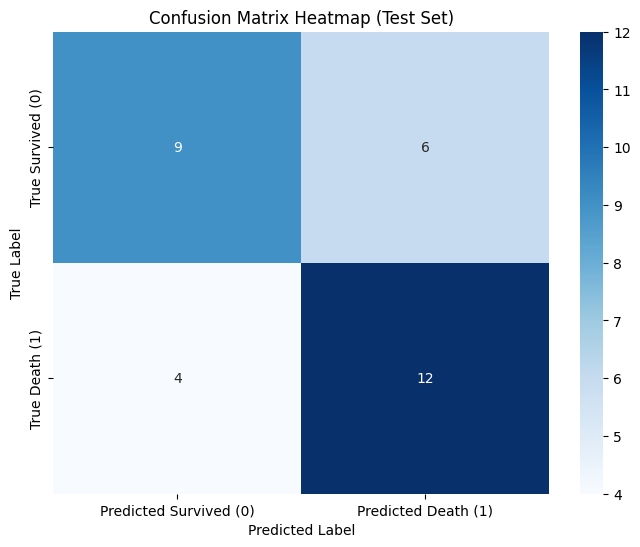

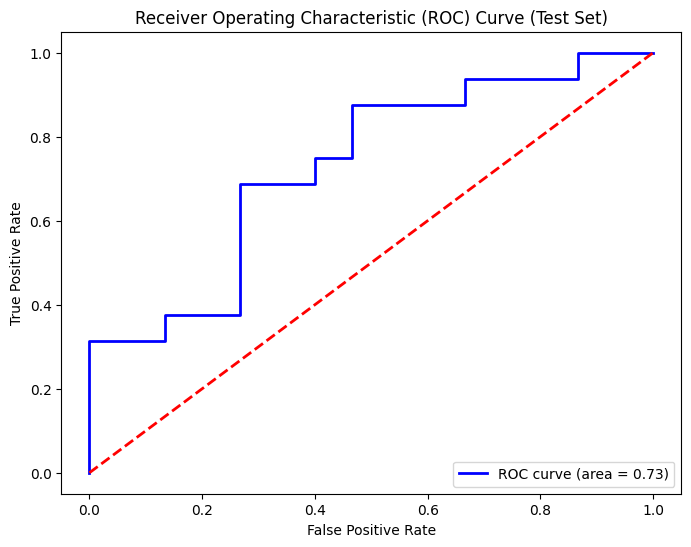


Data with highest PCA scores (most likely death):
     study_id  subject_id           study_datetime  \
61   55737000    11450442  2179-08-15 10:50:58.484   
30   56074012    10745072  2150-11-18 04:47:28.170   
332  59750727    19046950  2135-02-11 21:31:23.156   
302  59278177    18249179  2188-01-26 05:08:28.045   
121  54706917    13138475  2143-09-14 08:39:27.828   
..        ...         ...                      ...   
263  55874195    17125981  2152-12-21 08:55:46.039   
167  59226066    14280192  2163-10-13 21:36:11.953   
84   55651857    11959638  2178-09-13 05:04:40.078   
349  51492038    19919980  2124-07-25 20:02:25.546   
104  54822658    12719912  2146-05-13 21:19:50.703   

                                  path  \
61   files/p11/p11450442/s55737000.txt   
30   files/p10/p10745072/s56074012.txt   
332  files/p19/p19046950/s59750727.txt   
302  files/p18/p18249179/s59278177.txt   
121  files/p13/p13138475/s54706917.txt   
..                                 ...   
263  f

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming embeddings and icu_mortality are loaded into df
# Load your dataset into a pandas DataFrame
# df = pd.read_csv('your_dataset.csv')

# Extract embedding vectors and icu_mortality
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]
mortality = df['icu_mort']

# Balance the classes using undersampling first
df_0 = df[df['icu_mort'] == 0]
df_1 = df[df['icu_mort'] == 1]

# Undersample the majority class (icu_mort = 0) to match the minority class (icu_mort = 1)
if len(df_0) > len(df_1):
    df_0 = df_0.sample(len(df_1), random_state=42)
else:
    df_1 = df_1.sample(len(df_0), random_state=42)

# Combine the undersampled data
df_balanced = pd.concat([df_0, df_1])

# Extract the balanced embeddings and mortality
embeddings_balanced = df_balanced[embedding_columns]
mortality_balanced = df_balanced['icu_mort']

# Apply PCA
pca = PCA(n_components=50)
embeddings_pca = pca.fit_transform(embeddings_balanced)

# Add PCA components to the DataFrame
for i in range(embeddings_pca.shape[1]):
    df_balanced[f'pca_{i+1}'] = embeddings_pca[:, i]

# Prepare the data for classification analysis
X = df_balanced[[f'pca_{i+1}' for i in range(50)]]
y = mortality_balanced

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Define the classification model
model = LogisticRegression(max_iter=1000, penalty='l2', solver='lbfgs')  # Increase max_iter for convergence

# Train the model on the SMOTE-augmented training set
model.fit(X_train_smote, y_train_smote)

# Predict on the training set
y_train_pred = model.predict(X_train)
y_train_prob = model.predict_proba(X_train)[:, 1]

# Predict on the test set
y_test_pred = model.predict(X_test)
y_test_prob = model.predict_proba(X_test)[:, 1]

# Evaluate model on the training set
train_accuracy = accuracy_score(y_train, y_train_pred)
train_roc_auc = roc_auc_score(y_train, y_train_prob)
train_conf_matrix = confusion_matrix(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy}")
print(f"Training ROC-AUC: {train_roc_auc}")
print("Training Confusion Matrix:")
print(train_conf_matrix)

# Evaluate model on the test set
test_accuracy = accuracy_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_prob)
test_conf_matrix = confusion_matrix(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy}")
print(f"Test ROC-AUC: {test_roc_auc}")
print("Test Confusion Matrix:")
print(test_conf_matrix)

# Print the classification report for the test set
print("Classification Report (test set):")
print(classification_report(y_test, y_test_pred, target_names=['Survived (0)', 'Death (1)']))

# Plot the confusion matrix as a heatmap for the test set
plt.figure(figsize=(8, 6))
sns.heatmap(test_conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Survived (0)', 'Predicted Death (1)'], yticklabels=['True Survived (0)', 'True Death (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap (Test Set)')
plt.show()

# Plot ROC curve for the test set
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % test_roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Test Set)')
plt.legend(loc="lower right")
plt.show()

# Extract the raw data for highest and lowest PCA scores
# Calculate PCA scores
significant_components_indices = [i-1 for i in significant_components]  # Adjust for zero-indexing
pca_scores = np.dot(X, pca.components_[:])

# Identify the indices of the highest and lowest scores
highest_score_idx = np.argmax(pca_scores, axis=0)
lowest_score_idx = np.argmin(pca_scores, axis=0)

# Extract the corresponding rows from the original dataset
highest_score_data = df_balanced.iloc[highest_score_idx]
lowest_score_data = df_balanced.iloc[lowest_score_idx]

print("\nData with highest PCA scores (most likely death):")
print(highest_score_data)

print("\nData with lowest PCA scores (most likely survival):")
print(lowest_score_data)


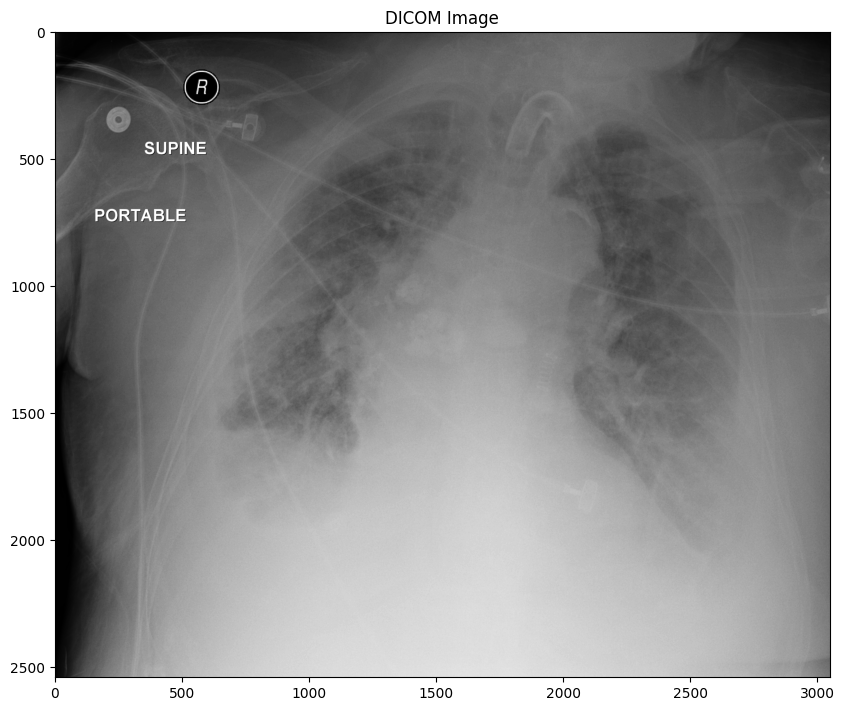

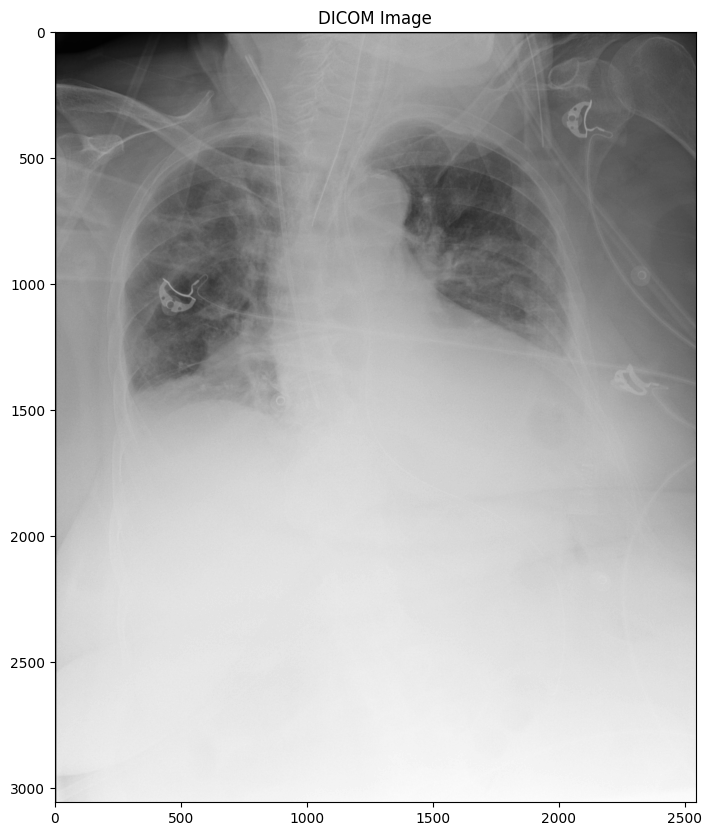

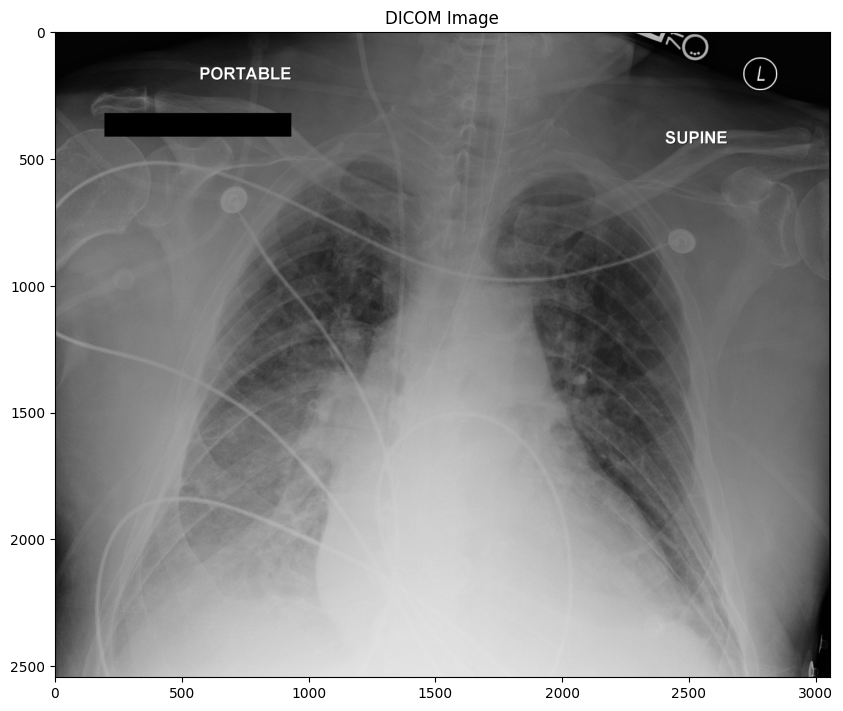

In [ ]:
import numpy as np
import tensorflow as tf
import pydicom
import matplotlib.pyplot as plt
from google.cloud import storage
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from PIL import Image

# Initialize the GCP client and bucket
client = storage.Client()
bucket = client.bucket('cxr_embedding')

# Path to the DICOM file
dicom_path = '/tmp/example1.dcm'

# Download the DICOM file from the GCP bucket
blob = bucket.blob('Mort_images/2fd1e5d8-712dc8b9-5d2552dc-36e64ec0-4d826f76.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Display the DICOM image
plt.figure(figsize=(10, 10))
plt.imshow(image_array, cmap='gray')
plt.title('DICOM Image')
plt.show()

# Download the DICOM file from the GCP bucket
blob = bucket.blob('Mort_images/3dd8ce41-dffa34fc-df91d380-400ab49d-6208d773.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Display the DICOM image
plt.figure(figsize=(10, 10))
plt.imshow(image_array, cmap='gray')
plt.title('DICOM Image')
plt.show()

# Download the DICOM file from the GCP bucket
blob = bucket.blob('Mort_images/10784af9-0c58b44c-5fd52a8b-662e0a5e-5479d073.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Display the DICOM image
plt.figure(figsize=(10, 10))
plt.imshow(image_array, cmap='gray')
plt.title('DICOM Image')
plt.show()

# Data preparation (unfiltered)

In [2]:
!pip install pydicom
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from google.colab import auth
from google.cloud import bigquery, storage

# Authenticate and set up environment
auth.authenticate_user()
project_id = 'mcxrp-429811'
os.environ["GOOGLE_CLOUD_PROJECT"] = project_id
!gcloud config set project {project_id}

# Initialize BigQuery client
client = bigquery.Client(project=project_id)

# Initialize GCP Storage client with user_project parameter
storage_client = storage.Client(project=project_id)
bucket_name = 'cxr_embedding'
bucket = storage_client.bucket(bucket_name, user_project=project_id)

# Path to the filtered combined data CSV in your GCP bucket
filtered_data_path = 'final_combined_data.csv'
filtered_blob = bucket.blob(filtered_data_path)

# Download the filtered combined data CSV to a local temporary file
local_filtered_data_path = '/tmp/final_combined_data.csv'
filtered_blob.download_to_filename(local_filtered_data_path)

# Load the filtered combined data CSV into a DataFrame
df = pd.read_csv(local_filtered_data_path)

# Extract embedding vectors
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 5.2 MB/s eta 0:00:00
Updated property [core/project].


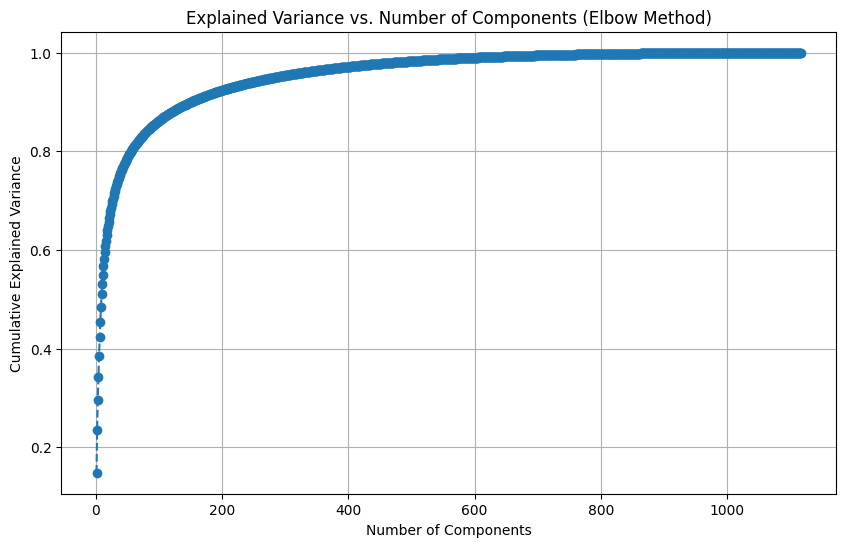

The optimal number of components based on silhouette score is: 62
[[-4.62993837  2.18177171 -3.13937452 ... -0.09288866  0.10588121
   0.73736895]
 [-3.84081017  1.38279085  1.29619876 ... -1.88166412  0.09581692
  -1.49081591]
 [-5.97690624 -0.35364261 -0.22087192 ... -0.67524866  0.57047681
   0.80590705]
 ...
 [-3.41695376  3.7709602  -6.04413886 ...  1.3334361  -0.83643836
  -1.12650735]
 [14.07613177 -6.67155879  3.9994167  ...  0.32964843 -0.64376264
   0.45701104]
 [-9.28944469  2.48160608 -3.18441926 ...  0.87719306  0.72572038
   0.29456212]]
62
1117


In [3]:
# Determine the optimal number of PCA components using the elbow method
pca = PCA()
embeddings_pca = pca.fit_transform(embeddings)
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot the explained variance to use the elbow method
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components (Elbow Method)')
plt.grid()
plt.show()

# Using the Silhouette method to determine the optimal number of components
def optimal_number_of_components(data, max_components=10):
    silhouette_scores = []
    for n_components in range(2, max_components + 1):
        pca = PCA(n_components=n_components)
        transformed_data = pca.fit_transform(data)
        kmeans = KMeans(n_clusters=n_components, n_init=10)  # Explicitly set n_init
        kmeans.fit(transformed_data)
        score = silhouette_score(transformed_data, kmeans.labels_)
        silhouette_scores.append(score)

    plt.figure(figsize=(10, 6))
    plt.plot(range(2, max_components + 1), silhouette_scores, marker='o', linestyle='--')
    plt.xlabel('Number of Components')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Score vs. Number of Components')
    plt.grid()
    plt.show()

    optimal_components = np.argmax(silhouette_scores) + 2  # +2 because range starts at 2
    return optimal_components

# Display optimal number of features using silhouette score
optimal_components = 62
print(f'The optimal number of components based on silhouette score is: {optimal_components}')

# Apply PCA with optimal number of components
pca = PCA(n_components=optimal_components)
embeddings_pca = pca.fit_transform(embeddings)

# Add PCA components to the dataframe
for i in range(embeddings_pca.shape[1]):
    df[f'pca_{i+1}'] = embeddings_pca[:, i]

print (embeddings_pca)
print (len(embeddings_pca[0]))
print (len(embeddings_pca))

# Logistic regression (unfiltered)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import statsmodels.api as sm

# Assuming embeddings is a numpy array with your embedding data
# and df is your original DataFrame

# Choose the number of components based on the elbow method graph
chosen_components = 50

# Apply PCA with chosen number of components
pca = PCA(n_components=chosen_components)
embeddings_pca = pca.fit_transform(embeddings)

# Add PCA components to the dataframe using pd.concat to avoid fragmentation
pca_columns = pd.DataFrame(embeddings_pca, columns=[f'pca_{i+1}' for i in range(chosen_components)])
df = pd.concat([df.reset_index(drop=True), pca_columns.reset_index(drop=True)], axis=1)

# Check for NaN values in the dataset
if df.isnull().values.any():
    print("Data contains NaN values. Please handle missing data before running regression.")
    print(df.isnull().sum())
else:
    # Prepare the data for regression analysis
    X = df[[f'pca_{i+1}' for i in range(chosen_components)]]
    y = df['icu_mort']

    # Ensure data types are correct
    if not np.issubdtype(y.dtype, np.number):
        print("The target variable 'icu_mort' must be numeric.")
    else:
        # Univariate PCA logistic regression (changing from multivariate to univariate)
        # Here we use each PCA component individually to fit the regression model
        significant_components = []
        for i in range(chosen_components):
            Xi = sm.add_constant(X[[f'pca_{i+1}']])
            model = sm.OLS(y, Xi)
            result = model.fit()
            p_value = result.pvalues.iloc[1]  # Access the p-value of the PCA component coefficient by position using iloc
            if p_value < 0.1:
                significant_components.append(i+1)
                print(f'Regression summary for PCA component {i+1}')
                print(result.summary())

# Save the significant components as a list
print("Significant PCA components:", significant_components)


Regression summary for PCA component 7
                            OLS Regression Results                            
Dep. Variable:               icu_mort   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     4.424
Date:                Wed, 07 Aug 2024   Prob (F-statistic):             0.0127
Time:                        10:04:05   Log-Likelihood:                -184.12
No. Observations:                 352   AIC:                             374.2
Df Residuals:                     349   BIC:                             385.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        

Best parameters: {'C': 10.0}
Cross-Validation Accuracy scores: [0.64150943 0.60377358 0.68867925 0.59047619 0.59047619]
Mean CV Accuracy: 0.6229829290206649


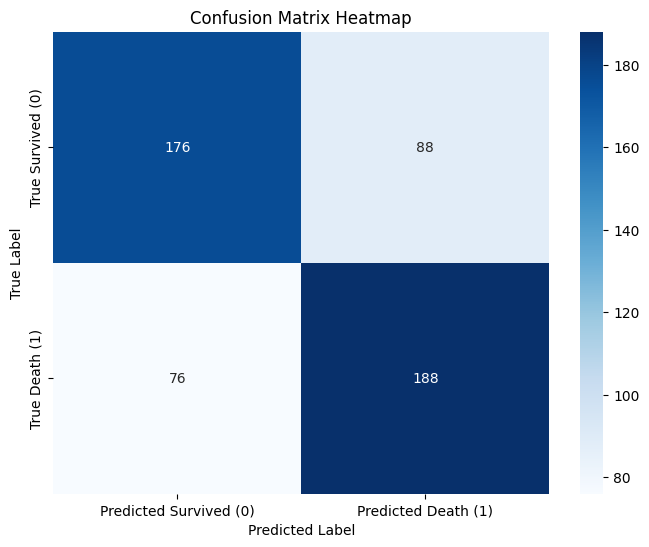

              precision    recall  f1-score   support

Survived (0)       0.70      0.67      0.68       264
   Death (1)       0.68      0.71      0.70       264

    accuracy                           0.69       528
   macro avg       0.69      0.69      0.69       528
weighted avg       0.69      0.69      0.69       528

Overall Accuracy: 0.6893939393939394
AUROC: 0.7798869375573921


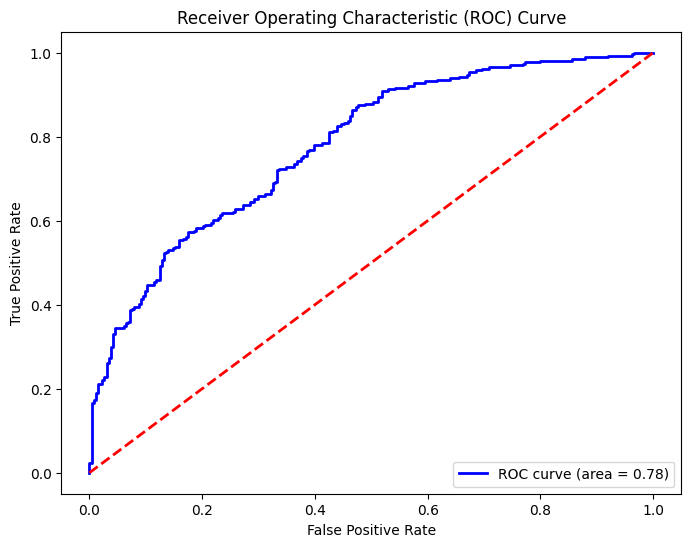


Correct Predictions:
     study_id  subject_id           study_datetime  \
86   53298751    14398566  2154-11-07 04:50:54.484   
274  56051012    18264198  2149-03-29 13:26:53.132   
856  51541295    11277562  2127-08-14 14:20:13.421   
708  52237928    18153920  2123-01-05 13:59:26.875   
369  59171660    18148412  2183-03-20 07:59:43.937   

                                  path  \
86   files/p14/p14398566/s53298751.txt   
274  files/p18/p18264198/s56051012.txt   
856  files/p11/p11277562/s51541295.txt   
708  files/p18/p18153920/s52237928.txt   
369  files/p18/p18148412/s59171660.txt   

                                         dicom_id  days_from_start  \
86   2675e51e-b3ebce07-be7723c2-af539cb4-5d5ce6b7                0   
274  0a672964-fbe538a8-679040e7-24fba754-32ad9167               10   
856  3c1e5682-e3f2aacd-4544de26-8c7a2d40-39685eb0               17   
708  fcdf145e-ca0405ea-bb7b3661-b08820fd-50d607df                8   
369  ea3e37ae-6f17ebb9-13d5e8b8-62721561-3b2d5710 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming embeddings and icu_mortality are loaded into df
# Load your dataset into a pandas DataFrame
# df = pd.read_csv('your_dataset.csv')

# Extract embedding vectors and icu_mortality
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]
mortality = df['icu_mort']

# Balance the classes
df_0 = df[df['icu_mort'] == 0]
df_1 = df[df['icu_mort'] == 1]

# Undersample the majority class (icu_mort = 0) to match the minority class (icu_mort = 1)
if len(df_0) > len(df_1):
    df_0 = df_0.sample(len(df_1), random_state=42)
else:
    df_1 = df_1.sample(len(df_0), random_state=42)

# Combine the balanced data
df_balanced = pd.concat([df_0, df_1])

# Extract the balanced embeddings and mortality
embeddings_balanced = df_balanced[embedding_columns]
mortality_balanced = df_balanced['icu_mort']

# Apply PCA
pca = PCA(n_components=50)
embeddings_pca = pca.fit_transform(embeddings_balanced)

# Add PCA components to the DataFrame
for i in range(embeddings_pca.shape[1]):
    df_balanced[f'pca_{i+1}'] = embeddings_pca[:, i]

# Prepare the data for classification analysis
X = df_balanced[[f'pca_{i+1}' for i in range(50)]]
y = mortality_balanced

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define the classification model
model = LogisticRegression(max_iter=1000, penalty='l2', solver='lbfgs')  # Increase max_iter for convergence

# Perform cross-validation and hyperparameter tuning
param_grid = {'C': [0.01, 0.1, 1.0, 10.0, 100.0]}  # Adding more values for C to explore regularization effect
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_scaled, y)

# Best model from grid search
best_model = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)

# Train the best model on the full dataset
best_model.fit(X_scaled, y)

# Cross-validation scores
cv_scores = cross_val_score(best_model, X_scaled, y, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

# Predict on the entire dataset
y_pred = best_model.predict(X_scaled)
y_pred_prob = best_model.predict_proba(X_scaled)[:, 1]

# Add predictions to the DataFrame
df_balanced['predicted_icu_mortality'] = y_pred

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Survived (0)', 'Predicted Death (1)'], yticklabels=['True Survived (0)', 'True Death (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

# Print the classification report
print(classification_report(y, y_pred, target_names=['Survived (0)', 'Death (1)']))

# Calculate and print the accuracy score
accuracy = accuracy_score(y, y_pred)
print("Overall Accuracy:", accuracy)

# Calculate and print the AUROC score
roc_auc = roc_auc_score(y, y_pred_prob)
print("AUROC:", roc_auc)

# Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Identify correct and incorrect predictions
correct_predictions = df_balanced.index[y == y_pred]
incorrect_predictions = df_balanced.index[y != y_pred]

# Display some rows from the raw dataset where predictions were correct
print("\nCorrect Predictions:")
print(df_balanced.loc[correct_predictions].head())

# Display some rows from the raw dataset where predictions were incorrect
print("\nIncorrect Predictions:")
print(df_balanced.loc[incorrect_predictions].head())


# SMOTE data augmentation

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming embeddings and icu_mortality are loaded into df
# Load your dataset into a pandas DataFrame
# df = pd.read_csv('your_dataset.csv')

# Extract embedding vectors and icu_mortality
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]
mortality = df['icu_mort']

# Undersample the majority class (icu_mort = 0) to match the minority class (icu_mort = 1)
if len(df_0) > len(df_1):
    df_0 = df_0.sample(len(df_1), random_state=42)
else:
    df_1 = df_1.sample(len(df_0), random_state=42)

# Combine the undersampled data
df_balanced = pd.concat([df_0, df_1])

# Extract the balanced embeddings and mortality
embeddings_balanced = df_balanced[embedding_columns]
mortality_balanced = df_balanced['icu_mort']

# Apply PCA
pca = PCA(n_components=50)
embeddings_pca = pca.fit_transform(embeddings_balanced)

# Add PCA components to the DataFrame
for i in range(embeddings_pca.shape[1]):
    df_balanced[f'pca_{i+1}'] = embeddings_pca[:, i]

# Prepare the data for classification analysis
X = df_balanced[[f'pca_{i+1}' for i in range(50)]]
y = mortality_balanced

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Define the classification model
model = LogisticRegression(max_iter=, penalty='l2', solver='lbfgs')  # Increase max_iter for convergence

# Train the model on the SMOTE-augmented training set
model.fit(X_train_smote, y_train_smote)

# Predict on the training set
y_train_pred = model.predict(X_train)
y_train_prob = model.predict_proba(X_train)[:, 1]

# Predict on the test set
y_test_pred = model.predict(X_test)
y_test_prob = model.predict_proba(X_test)[:, 1]

# Evaluate model on the training set
train_accuracy = accuracy_score(y_train, y_train_pred)
train_roc_auc = roc_auc_score(y_train, y_train_prob)
train_conf_matrix = confusion_matrix(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy}")
print(f"Training ROC-AUC: {train_roc_auc}")
print("Training Confusion Matrix:")
print(train_conf_matrix)

# Evaluate model on the test set
test_accuracy = accuracy_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_prob)
test_conf_matrix = confusion_matrix(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy}")
print(f"Test ROC-AUC: {test_roc_auc}")
print("Test Confusion Matrix:")
print(test_conf_matrix)

# Print the classification report for the test set
print("Classification Report (test set):")
print(classification_report(y_test, y_test_pred, target_names=['Survived (0)', 'Death (1)']))

# Plot the confusion matrix as a heatmap for the test set
plt.figure(figsize=(8, 6))
sns.heatmap(test_conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Survived (0)', 'Predicted Death (1)'], yticklabels=['True Survived (0)', 'True Death (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap (Test Set)')
plt.show()

# Plot ROC curve for the test set
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % test_roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Test Set)')
plt.legend(loc="lower right")
plt.show()

SyntaxError: invalid syntax (<ipython-input-1-af094f3c3cfc>, line 58)